# Ecuación de Burgers

In [1]:
%matplotlib inline

In [2]:
import numpy as np
from matplotlib import pyplot as plt

## Parámetros

In [61]:
L  = 1.0           # longitud del sistema 1D
nx = 50            # nodos espaciales
dx = L / nx
x = np.linspace( 0 , L - dx , num=nx )

T= 1               # tiempo total
nt = T*1000            # pasos temporales
dt = T / nt

D = 1              # difusividad

In [35]:
def chistera(L, x1, x2,nx) :
    u = np.zeros( nx )
    dx = L / (nx-2) 
    n1 = int(x1 / dx)
    n2 = int(x2 / dx)
    u[ n1 : n2 ] = 1
    return u

In [36]:
def gaussiana(L, mean, sigma, nx) :
    u = np.zeros( nx )
    dx = L / (nx-2) 

    for i in range(0,nx):
        x = i * dx - mean
        u[i] = np.exp( - (x/sigma)**2 / 2)

    return u

### Números de Courant

In [6]:
Co_D = D * dt / dx**2
Co_D

0.31999999999999995

### Condiciones iniciales

In [53]:
u0 = gaussiana(L, 0.5, 0.1,nx)

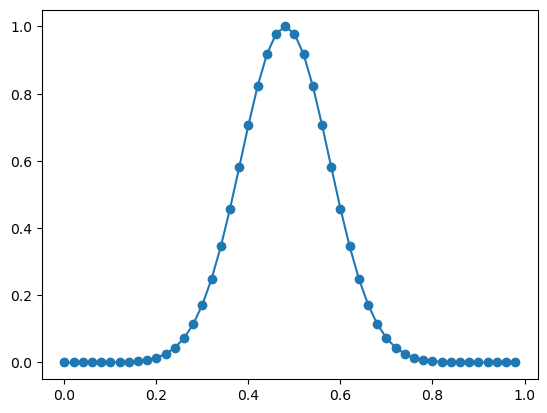

In [54]:
plt.plot( x , u0 , 'o-')

### Un paso en el tiempo

Queremos implementar $u_i^{n+1} = u_i^n + \mathrm{Co}_D (u_{i+1}^n +  u_{i-1}^n  - 2 u_i^n)$ + convección no lineal

In [12]:
u = u0.copy()

In [13]:
un = u.copy()         # distribución actual

#i=0
#u[i] = un[i] + Co_D * (un[i+1] + 1 - 2 * un[i] ) - Co  * (un[i] - 1)

for i in range( 0 , nx -1 ):
    Co = u[i]*dt/dx
    u[i] = un[i] + Co_D * (un[i+1] + un[i-1] - 2 * un[i] ) - Co  * (un[i] - un[i-1])

i = nx -1
Co = u[i]*dt/dx
u[i] = un[i] + Co_D * ( un[0] + un[i-1] - 2 * un[i] ) - Co  * (un[i] - un[i-1])


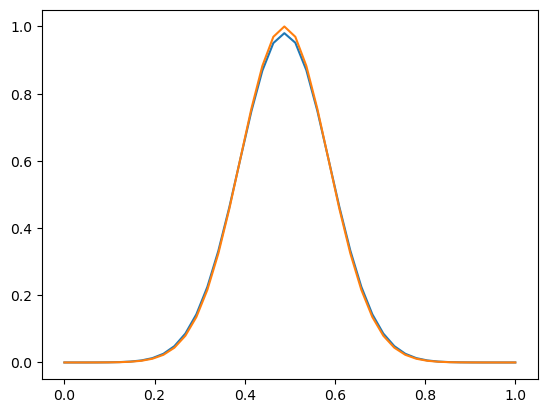

In [15]:
plt.plot( x , u, x, u0)

### Tiempo completo

In [62]:
D = 0.01              # difusividad

In [63]:
Co_D = D * dt / dx**2

print('Co_diff = ', Co_D)

Co_diff =  0.025


In [64]:
Co_max = np.max(u0) * dt / dx

print('Co max = ', Co_max)

Co max =  0.05


In [65]:
u = u0.copy()

In [66]:
for n in range(nt ):
    un = u.copy()
    
#    i=0
#    u[i] = un[i] + Co_D * (un[i+1] + 1 - 2 * un[i] ) - Co  * (un[i] - 1)
    
    for i in range( 0 , nx - 1 ):
            Co = u[i]*dt/dx
            u[i] = un[i] + Co_D * (un[i+1] + un[i-1] - 2 * un[i] ) - Co  * (un[i] - un[i-1])

    i = nx -1
    Co = u[i]*dt/dx
    u[i] = un[i] + Co_D * ( un[0] + un[i-1] - 2 * un[i] ) - Co  * (un[i] - un[i-1])


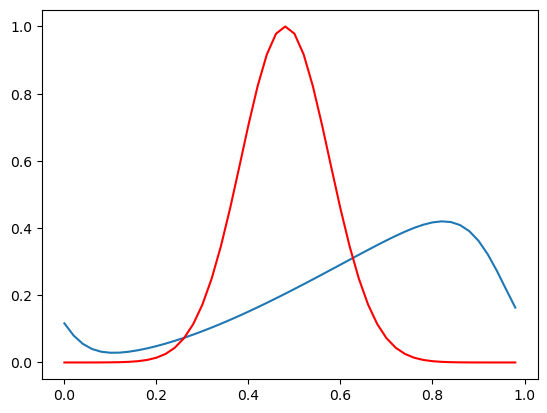

In [67]:
plt.plot(x , u , x , u0 , 'r')